<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h1>Breast Cancer data process</h1>
</div>

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h2>What is this notebook doing </h2>
    <p>
    - Loads cleaned data<br>
    - Cleans data<br>
    - processes data<br>
    - Saves ... `data/data_processed`<br>
    </p>
</div>

In [12]:

# import matplotlib.pyplot as plt
# import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from building_perceptron.config import CLEAN_DATA_DIR, TARGET
from building_perceptron.eda_utils import (
    feature_collinearity,
    plot_feature_collinearity,
    plot_numeric_histograms,
    plot_target_correlations,
    preprocess_data,
    scree_plot,
    target_correlations,
    plot_scatter_vs_target,
    select_best_features
)
from building_perceptron.model_utils import Perceptron, eval_classification


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>Import the source file with the proper encoding</p>
</div>

In [3]:

X_train = CLEAN_DATA_DIR / "X_train.csv"
y_train = CLEAN_DATA_DIR / "y_train.csv"
X_test = CLEAN_DATA_DIR / "X_test.csv"
y_test = CLEAN_DATA_DIR / "y_test.csv"


X_train = pd.read_csv(X_train, encoding='ascii')
y_train = pd.read_csv(y_train, encoding='ascii')
X_test = pd.read_csv(X_test, encoding='ascii')
y_test = pd.read_csv(y_test, encoding='ascii')

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()


In [4]:
print(f"\
    X_train type: {type(X_train)}\n\
    X_train shape : {X_train.shape}\n\
    y_train type : {type(y_train)}\n\
    y_train shape : {y_train.shape}"
    )

    X_train type: <class 'pandas.DataFrame'>
    X_train shape : (455, 30)
    y_train type : <class 'numpy.ndarray'>
    y_train shape : (455,)


<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px;border-radius: 8px;">
<p>preprocessing is done AFTER the train/test split<br>
scikit-learn pipelines garanty that transformations are learnt on training set only<br>
  - avoids data leakage<br>
  - statistics and scaling are learnt on train set only<br>
  </p>
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h4 style="margin: auto; padding: 20px; color: #439cc8; ">To maintain biological interpretability, feature selection is preffered to PCA</h4>


<h4 style="margin: auto; padding: 20px; color: #439cc8; ">Reduce multicollinearité before scaling to simplify model early</h4>
</div>

In [5]:
# Search for feature collinearity (over 90%)
collinear_pairs = feature_collinearity( X_train, threshold=0.9)

print("Pairs of strongly collinear features (over 90%) :\n")
for f1, f2, val in collinear_pairs:
    print(f"{f1} <-----> {f2} : {val:.4f}")

Pairs of strongly collinear features (over 90%) :

perimeter_mean <-----> radius_mean : 0.9978
perimeter_worst <-----> radius_worst : 0.9937
area_mean <-----> radius_mean : 0.9867
area_mean <-----> perimeter_mean : 0.9860
area_worst <-----> radius_worst : 0.9831
area_worst <-----> perimeter_worst : 0.9767
perimeter_se <-----> radius_se : 0.9747
perimeter_worst <-----> perimeter_mean : 0.9700
radius_worst <-----> perimeter_mean : 0.9693
radius_worst <-----> radius_mean : 0.9693
perimeter_worst <-----> radius_mean : 0.9644
radius_worst <-----> area_mean : 0.9607
area_worst <-----> area_mean : 0.9582
perimeter_worst <-----> area_mean : 0.9567
area_se <-----> radius_se : 0.9516
area_worst <-----> perimeter_mean : 0.9411
area_worst <-----> radius_mean : 0.9405
area_se <-----> perimeter_se : 0.9392
concave points_mean <-----> concavity_mean : 0.9206
concave points_worst <-----> concave points_mean : 0.9122
texture_worst <-----> texture_mean : 0.9117


In [6]:
# y_train_series = pd.Series(y_train_encoded)


# Top 10 features most related to the target variable
top_corr = target_correlations(X_train, y_train, n_top=10)

print(f"Top 10 features most related to {TARGET} :")
print(top_corr)

Top 10 features most related to diagnosis :
concave points_worst    0.786306
perimeter_worst         0.782881
radius_worst            0.777602
concave points_mean     0.775737
perimeter_mean          0.740027
area_worst              0.731761
radius_mean             0.728160
area_mean               0.703893
concavity_mean          0.683688
concavity_worst         0.643116
Name: __target__, dtype: float64


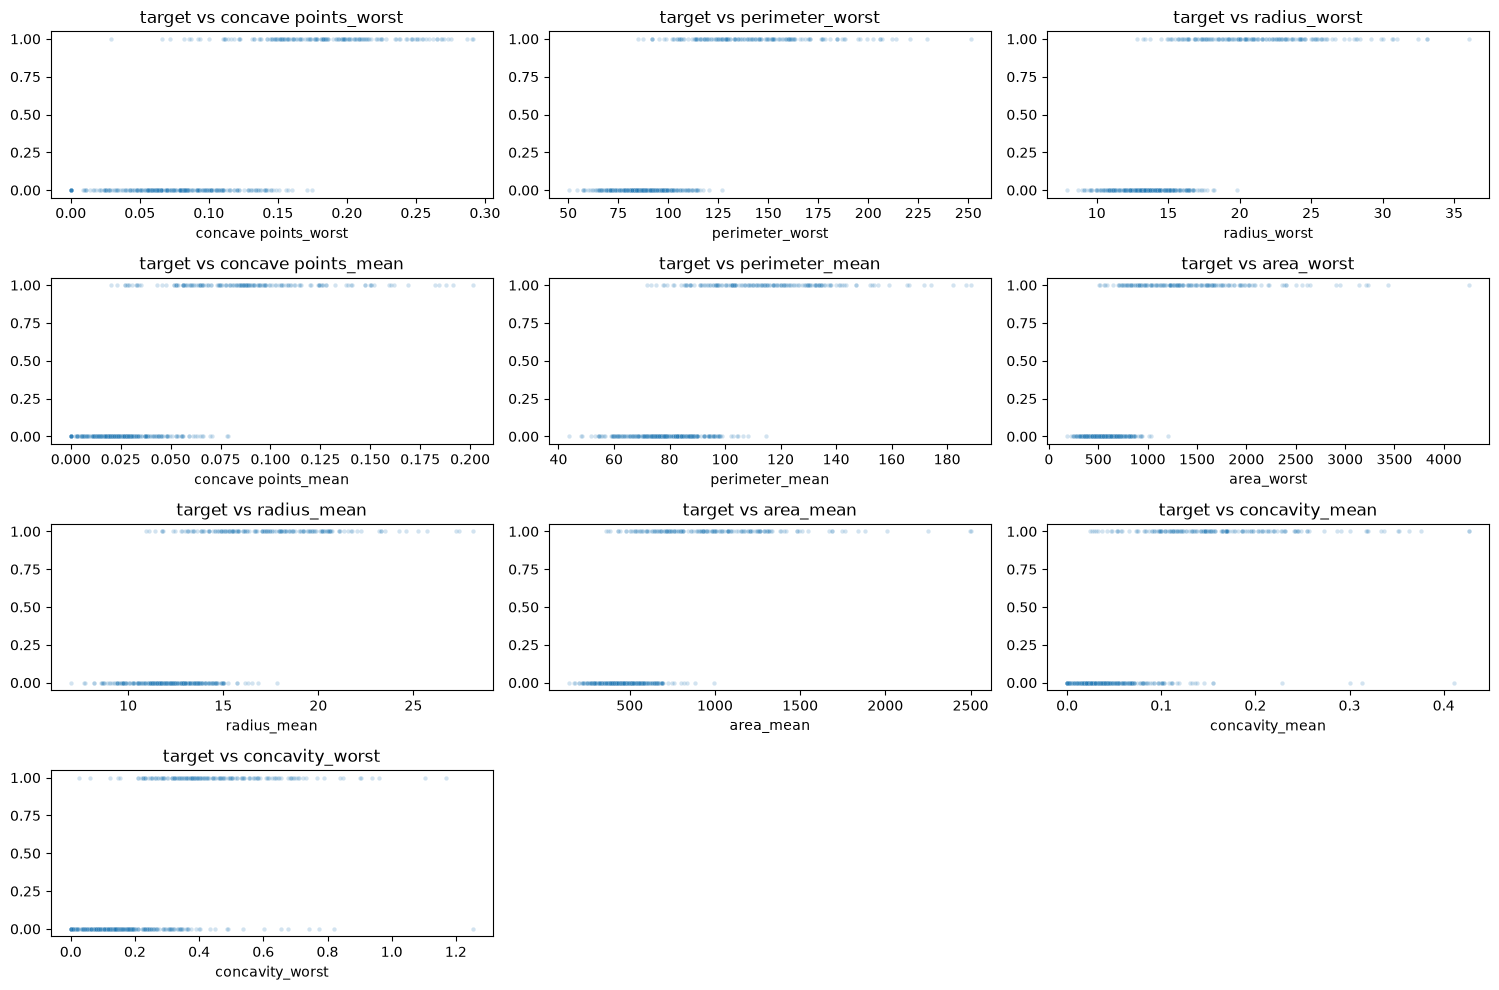

In [ ]:
top_cols = top_corr.index.tolist()
plot_scatter_vs_target(X_train, y_train, top_cols)

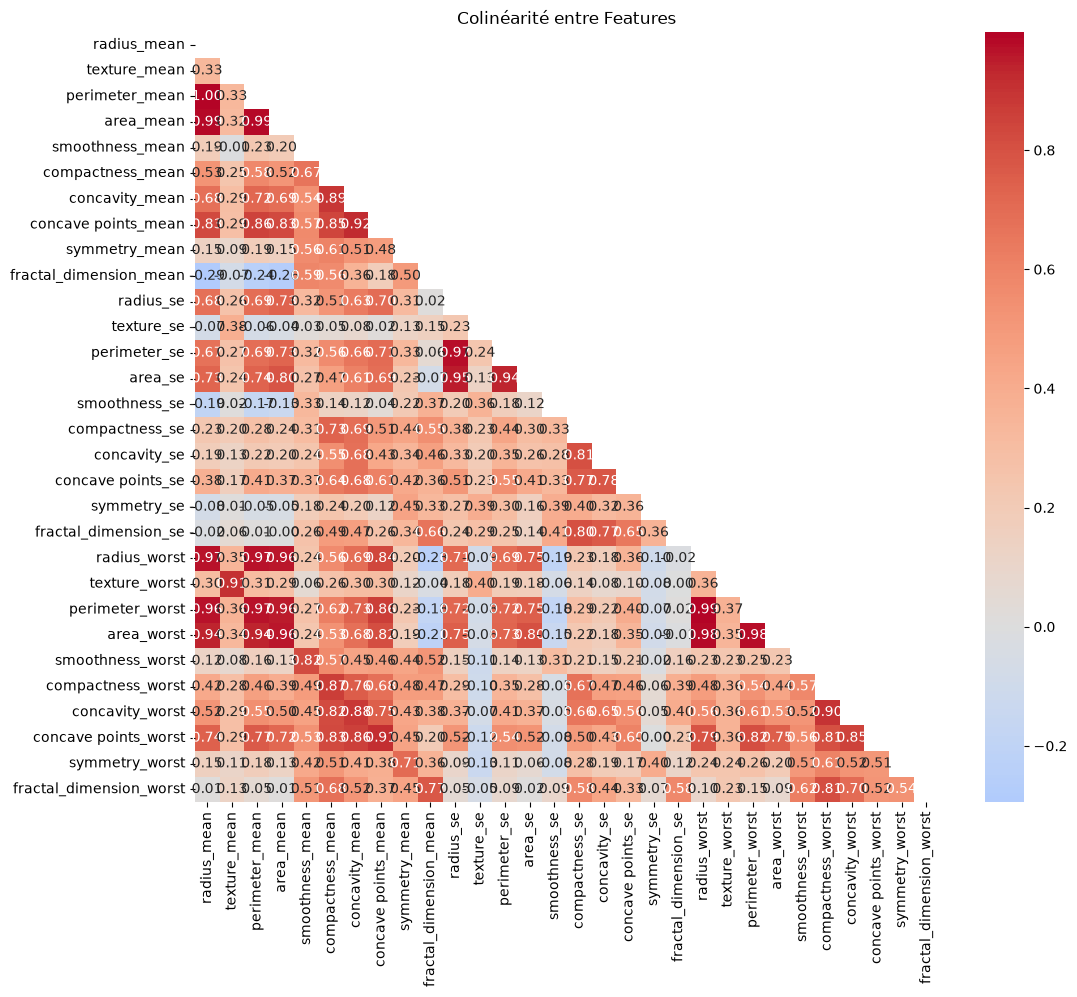

In [9]:
plot_feature_collinearity(X_train, figsize=(12, 10))

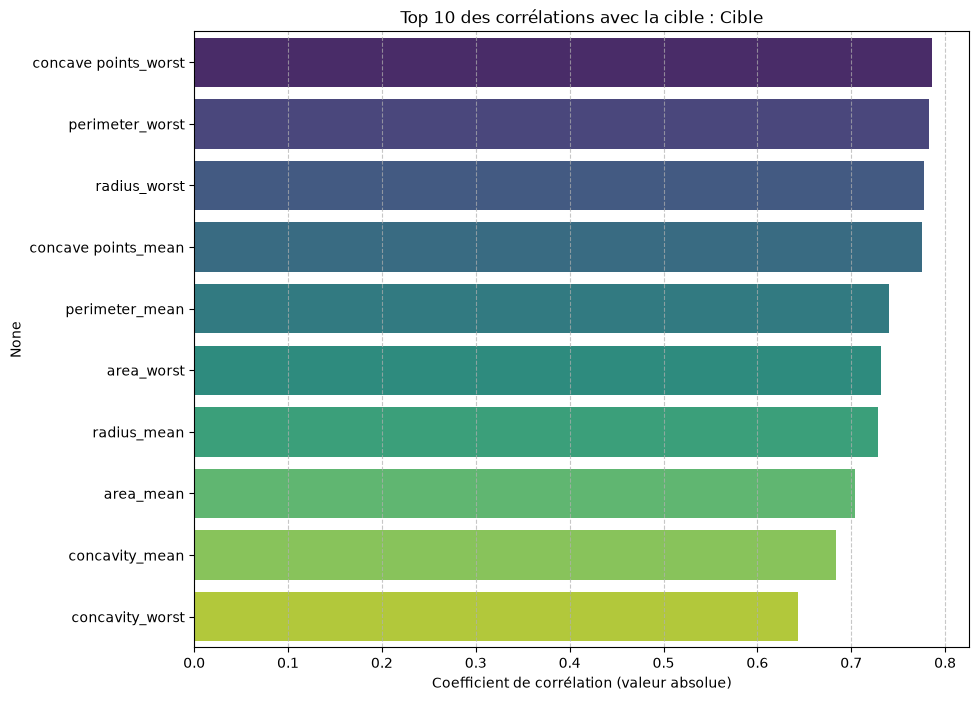

In [10]:
plot_target_correlations(X_train, y_train, n_top=10)

<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px; border-radius: 8px;">
  <h3>Analyse</h3>
</div>

In [13]:
X_train = select_best_features(X_train, y_train, threshold=0.90).copy()

--- Sélection de Features (Seuil: 0.9) ---
Total colonnes avant : 30
Colonnes supprimées  : 10
Détails : area_mean, area_se, area_worst, concave points_mean, concavity_mean, perimeter_mean, perimeter_se, radius_mean, radius_worst, texture_mean
Total colonnes après : 20
----------------------------------------


In [106]:
X_train.shape

(455, 20)

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%; color: #439cc8" >
<h4 style="margin: auto; padding: 20px; ">Réduction de la multicolinéarité par arbitrage de corrélation</h4>
<p style="margin: auto; padding: 20px; ">
Nous avons identifié des variables présentant une corrélation mutuelle supérieure à 0.90 (multicolinéarité forte). Afin de ne pas biaiser le Perceptron avec des données redondantes, nous avons appliqué l'algorithme suivant :

1. Détection des paires de variables redondantes.

2. Comparaison de la corrélation de chaque variable de la paire avec la cible (diagnosis).

3. Suppression de la variable la moins corrélée à la cible au sein de la paire.

Ce procédé a permis de supprimer 10 variables (passant de 30 à 20) tout en conservant les prédicteurs les plus puissants pour chaque groupe de caractéristiques physiques (taille, forme, texture).
</p>
</div>

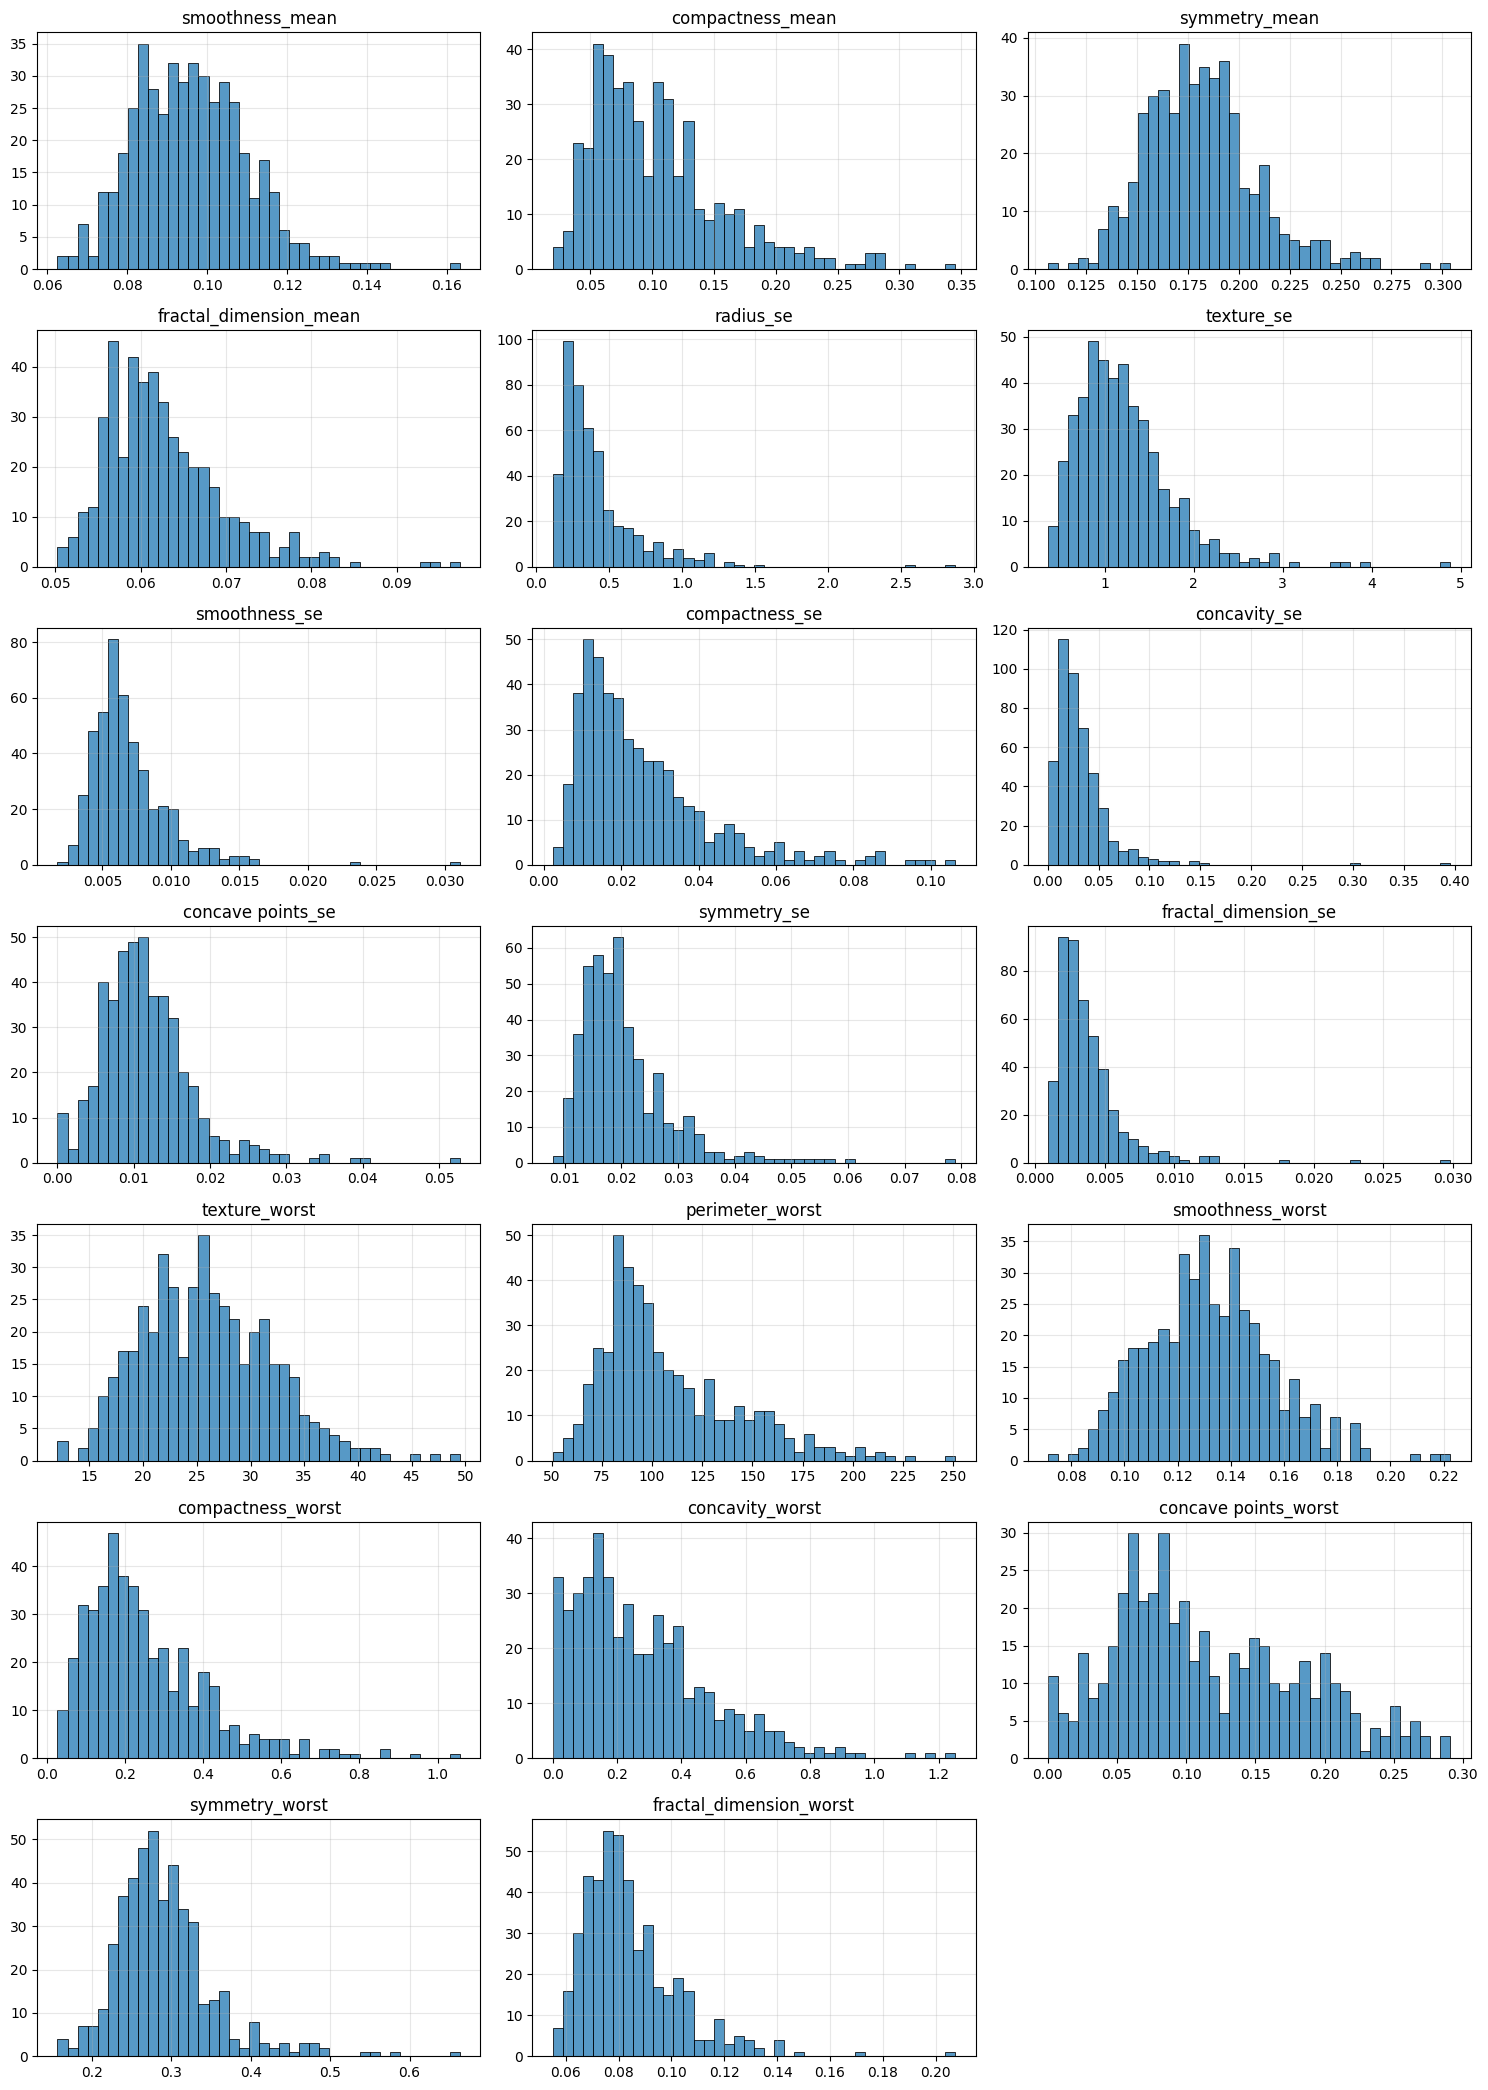

In [107]:
plot_numeric_histograms(X_train[numeric_columns])

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h4 style="margin: auto; padding: 20px; color: #439cc8; ">Preprocessing UNIQUEMENT sur les features d'entraînement</h4>
</div>

#### Examiner la distribution des variables numériques avant de choisir un scaler

In [ ]:
for var in X_train.columns:
    fig = px.box(X_train, x=var, title=f"Distribution de {var}", height=250)
    fig.show()


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%; color: #439cc8" >
<h4 style="margin: auto; padding: 20px; ">Sélection de l'outil de mise à l'échelle (scaler) suite à l'analyse de la distribution des variables numériques</h4>

1. Préservation de l'information :
`RobustScaler` car le dataset présente des distributions asymétriques avec des outliers importants dans les valeurs hautes. En utilisant la médiane et l'écart interquartile ($IQR$), nous normalisons les données sans que les valeurs extrêmes n'écrasent la variance des données saines

2. Performance du modèle :
Le Perceptron est un classifieur linéaire sensible à l'échelle des descripteurs. La mise à jour des poids lors de l'apprentissage est plus stable et rapide lorsque les variables sont sur une échelle comparable. Le RobustScaler garantit que les outliers ne causent pas de distorsions excessives dans le calcul de l'hyperplan de séparation.

3. Nature biologique : 
D'un point de vue biologique, ces outliers représentent des anomalies cellulaires réelles et critiques pour le diagnostic de malignité. Il était donc primordial d'utiliser un scaler qui harmonise les échelles sans supprimer ni masquer l'existence de ces signaux extrêmes.

</div>

In [109]:

'''
Preprocessing

numériques → RobustScaler()
catégorielles → OneHotEncoder(drop='first', handle_unknown='ignore')
'''
X_train, preprocessor = preprocess_data(X_train,
                                                    numeric_columns=numeric_columns,
                                                    # Il n'y a pas de variables catégorielles dans ce dataset
                                                    # categorical_columns=categorical_columns
                                                    )


In [110]:
# Vérification des valeurs des 2 premières observation après préprocessing
print(X_train[:2])

[[-0.66666667 -0.38414771 -0.8125937  -0.49570693  0.20728068  0.07574562
  -0.75316349 -0.57230688 -0.58292444 -0.47724495 -0.51314143 -0.03904365
   0.96440873  0.61005482 -0.40561622 -0.32361439 -0.31499906 -0.01275185
   0.18518519  0.21380309]
 [ 0.38239757 -0.33731142  0.47976012 -0.20034345 -0.36363636 -0.74704119
   0.60199089 -0.43930636 -0.35446516  0.21568768  0.06758448 -0.38736565
  -1.12973594 -0.24915432  0.23088924 -0.47333859 -0.39647081 -0.07232849
   0.00592593 -0.59749035]]




<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<hp style="margin: auto; padding: 20px; color: #439cc8; ">Ces arrays NumPy confirment que le preprocessing est réussi.

Les valeurs sont désormais centrées autour de 0 (avec des valeurs comme -0.66, 0.20, 0.96).

Avant : il y avait des rayons de tumeurs à 15.0 et des surfaces à 1000.0.

Maintenant : Tout est sur la même échelle<br>
Le Perceptron ne sera pas "aveuglé" par les grandes valeurs et pourra accorder la même importance mathématique à chaque variable.</p>
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">Transforme les features de test avec le même preprocesseur</h3>
</div>

In [111]:
X_test = preprocessor.transform(X_test)

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%; color: #439cc8">
<h4 style="margin: auto; padding: 20px;">PCA EDA avec target incluse</h4>
<p style="margin: auto; padding: 0 20px 20px 20px;">
Objectif : visualiser la séparation globale des classes en laissant la variable <strong>diagnosis</strong> influencer les axes principaux.<br>
Interprétation : utile pour une lecture orientée discrimination (exploration guidée par la cible).<br>
Limite : cette PCA n'est pas neutre vis-à-vis de la cible, donc elle ne doit pas servir de base au pipeline d'entraînement.
</p>
</div>

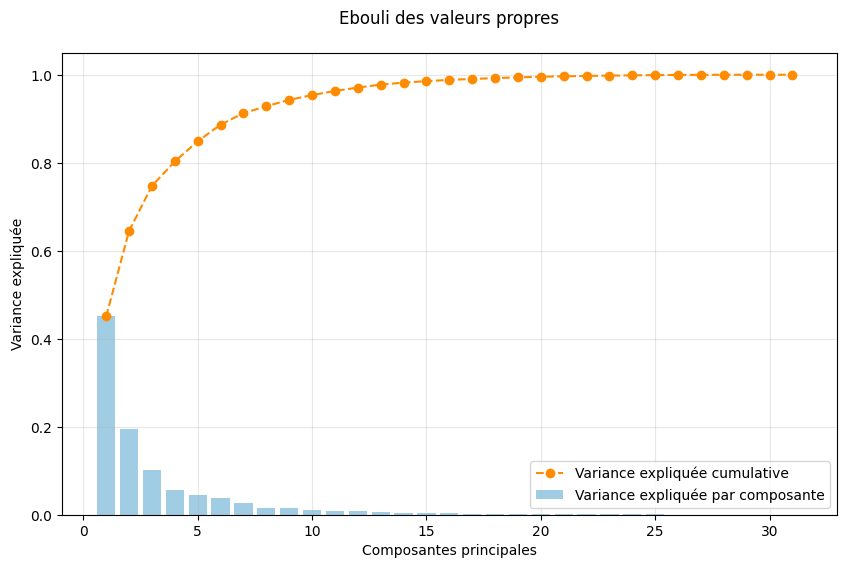

In [112]:
df_scaled, preprocessor = preprocess_data(df,
                                                    numeric_columns=numeric_columns,
                                                    # Il n'y a pas de variables catégorielles dans ce dataset
                                                    # categorical_columns=categorical_columns
                                                    )

# PCA pour l'EDA (cible incluse, uniquement pour exploration)
pca_with_target = PCA()
X_pca_with_target = pca_with_target.fit_transform(df_scaled)

scree_plot(pca_with_target)

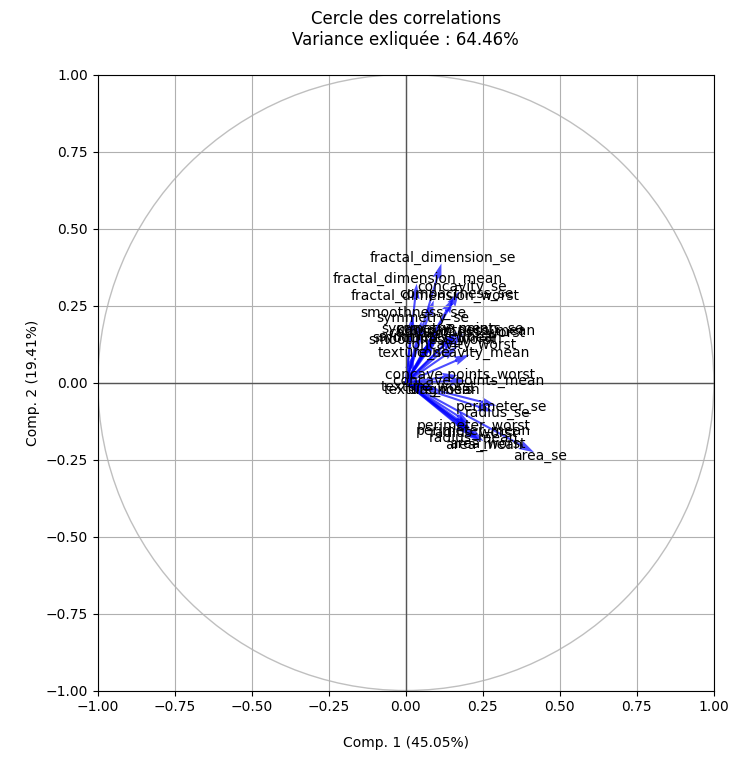

In [113]:
plot_correlation_circle(pca_with_target, [0, 1], df.columns)

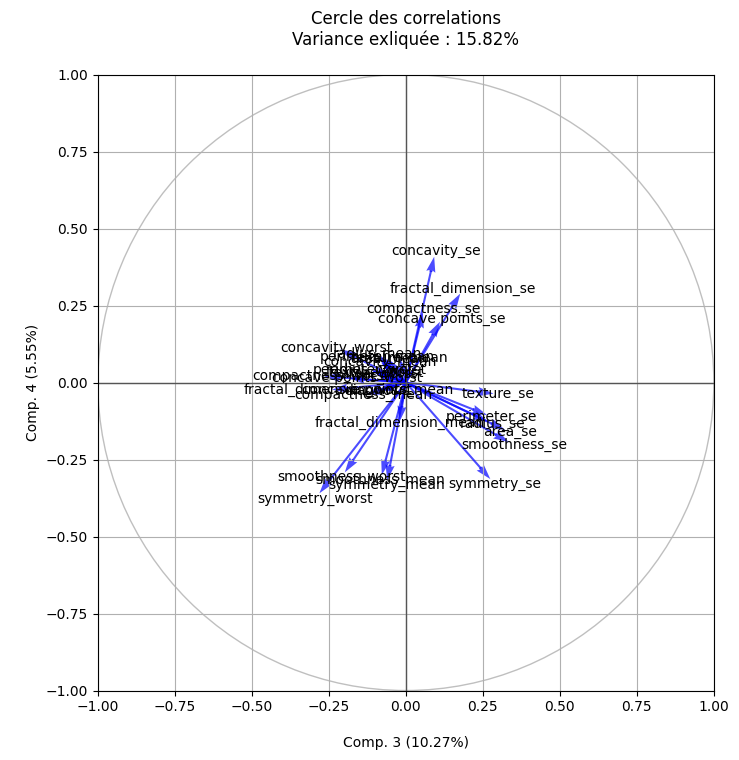

In [114]:
plot_correlation_circle(pca_with_target, [2, 3], df.columns)

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%; color: #439cc8">
<h4 style="margin: auto; padding: 20px;">PCA EDA sans target (non supervisée)</h4>
<p style="margin: auto; padding: 0 20px 20px 20px;">
Objectif : analyser la structure intrinsèque des variables explicatives uniquement (<strong>X</strong>).<br>
Interprétation : lecture plus fidèle des corrélations et de la redondance entre features.<br>
Usage recommandé : cette version est la référence pour comprendre la géométrie des données avant modélisation.
</p>
</div>

In [115]:
X_eda = df.drop(columns=[TARGET])
y_eda = df[TARGET]

X_eda_scaled, _ = preprocess_data(X_eda, numeric_columns=numeric_columns)
pca_no_target = PCA()
X_pca_no_target = pca_no_target.fit_transform(X_eda_scaled)


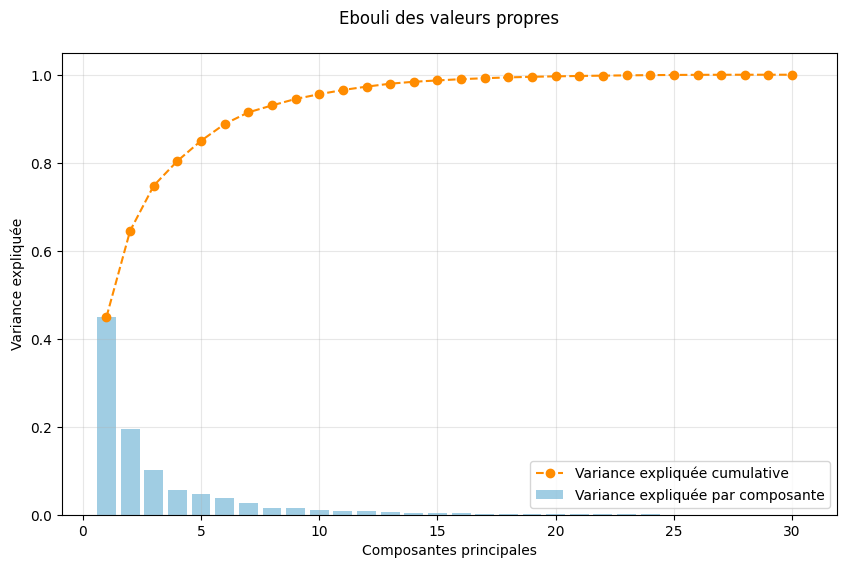

In [116]:
scree_plot(pca_no_target)

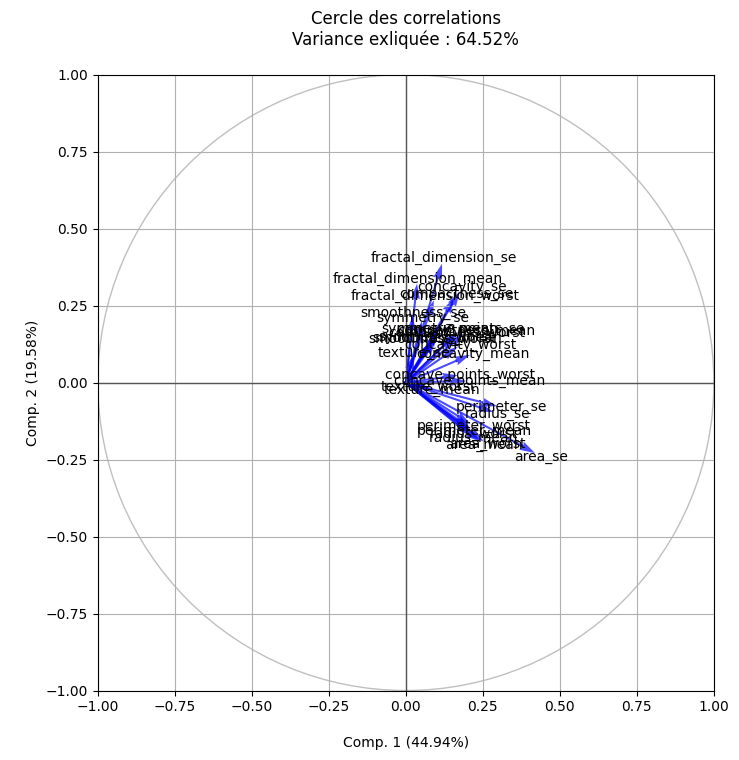

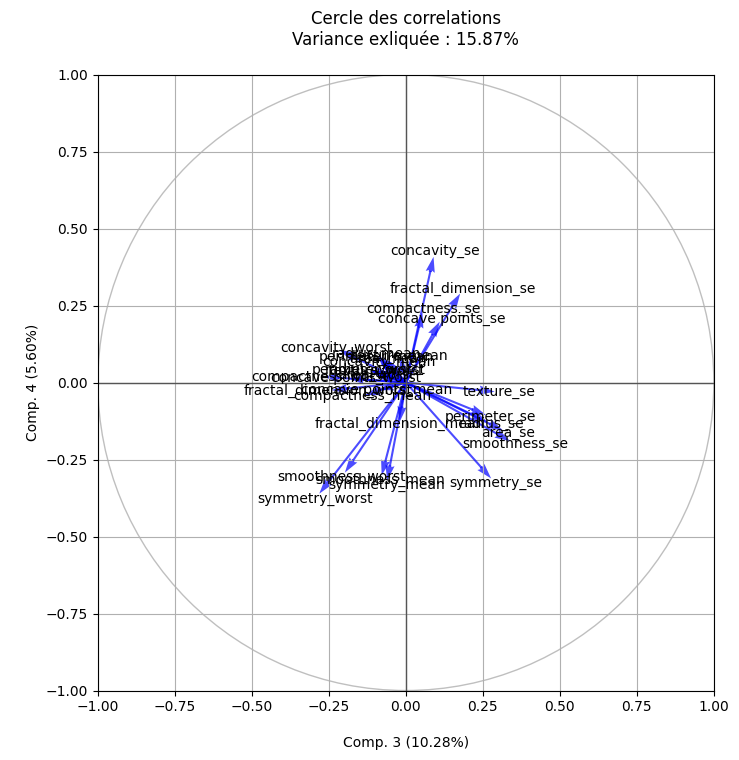

X_eda_scaled: (569, 30) | X_pca_no_target: (569, 30)


In [117]:
plot_correlation_circle(pca_no_target, [0, 1], X_eda.columns)
plot_correlation_circle(pca_no_target, [2, 3], X_eda.columns)
print(f"X_eda_scaled: {X_eda_scaled.shape} | X_pca_no_target: {X_pca_no_target.shape}")

<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px; border-radius: 8px;">
  <h3>Modèle de base : DummyCLassifier</h3>
</div>

In [118]:
print(type(y_train)) # Doit être <class 'pandas.core.series.Series'> ou <class 'numpy.ndarray'>
print(y_train.shape) # Doit être (n_samples,) et PAS (n_samples, 1)

<class 'pandas.Series'>
(455,)


In [119]:
# dc = DummyClassifier()

# param_grid_dc = {'strategy': ['most_frequent', 'prior','stratified', 'uniform']}

# results_dc = eval_classification(dc, param_grid_dc, X_train, y_train, X_test, y_test)

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%; color: #439cc8;" >
<hp style="margin: auto; padding: 20px ">
Accuracy (0.6316) :<br>
Dans le jeu de test, il y a environ 63% de tumeurs bénignes. Si l'on prédis "bénin" au hasard pour tout le monde, on a raison 63% du temps.<br>

Recall de la classe 1 (0.00) :<br>
Le modèle a raté 100% des tumeurs malignes (classe 1)<br>

F1-score de la classe 1 (0.00) :<br>
Le modele n'a trouvé aucun cas positif, son score d'efficacité pour la maladie est nul.
Preprocessing UNIQUEMENT sur les features d'entraînement</p>
</div>

<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px; border-radius: 8px;">
  <h3>Perceptron</h3>
</div>

In [120]:
X_train.shape

(455, 20)

In [ ]:
# # On définit une grille de paramètres simple pour le Perceptron (la fonction en attend une)
# param_grid = {
#     'n_iterations': [100, 500],
#     'learning_rate': [0.1, 0.01]
# }


# results_percep = eval_classification(
#     Perceptron(),
#     param_grid,
#     X_train,
#     y_train,
#     X_test,
#     y_test
# )

<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px; border-radius: 8px;">
  <h3>Analyse des performances</h3>

Comparaison avec la Baseline :<br>
Le Perceptron (95,6%) écrase littéralement le DummyClassifier (63,2%)

Cela prouve que le modèle a réellement appris des relations mathématiques dans les données et ne prédit pas au hasard.

Équilibre des classes : Les scores (F1-score) sont excellents pour la classe 0 (0.97) comme pour la classe 1 (0.94).<br>
Le modèle n'est pas "paresseux" et arrive à distinguer les deux types de tumeurs.

**Recall classe 1** : Le rappel pour les tumeurs malignes est de 0.93<br>
Cela signifie que sur 42 cas réels de cancer dans le jeu de test, le modèle en a détecté environ 39.<br>
<strong>Il en a raté 3</strong> (Faux Négatifs).

<h4>Conclusion sur l'efficacité</h4>
Le Perceptron s'avère extrêmement efficace pour cette problématique de santé.<br>
Avec une précision globale de 96%, il démontre que les caractéristiques morphologiques des cellules (rayon, symétrie, concavité)<br>
permettent de séparer les classes de manière quasi-linéaire.<br>
Cependant, dans un contexte médical, <strong>le taux de faux négatifs (7% des cas malins non détectés) reste un point de vigilance qui nécessiterait un ajustement du modèle.</strong>

<h4>Pistes d'amélioration proposées (Sans les implémenter)</h4>

**Changement de fonction d'activation :**<br>
Remplacer la fonction "seuil" (Heaviside Step Function) par une fonction Sigmoïde<br>
pour transformer le Perceptron en Régression Logistique.<br>
Cela permettrait d'obtenir une probabilité (ex: "80% de risque") plutôt qu'une réponse binaire, facilitant le diagnostic médical.

**Optimisation du Recall :**<br>
Modifier le seuil de décision (actuellement à 0.5) pour le descendre à 0.3.<br>
Cela augmenterait les faux positifs mais réduirait drastiquement les faux négatifs (on préfère s'inquiéter pour rien que de rater un cancer).

**Utilisation de modèles non-linéaires :**<br>
Tester un SVM (Support Vector Machine) avec un noyau RBF ou un Random Forest pour capturer des relations plus complexes entre les variables que le Perceptron ne peut pas voir à cause de sa nature linéaire.

**Faire du multicouche** la backpropagation permetrait d'ajuster les poids et d'améliorer la prédiction.

</div>